# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [ ]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [5]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [6]:
original_stats = data.describe().loc[['mean', 'std', 'min', 'max']]
minmax_stats = data_minmax.describe().loc[['mean', 'std', 'min', 'max']]

comparison_stats = pd.concat(
    [original_stats, minmax_stats],
    axis=1,
    keys=['Original', 'MinMax']
)

display(comparison_stats)

print("Conclusión rápida:")
print("- MinMax transforma cada variable al rango [0, 1].")
print("- Se preserva la forma general de la distribución, pero cambia la escala.")
print("- Las magnitudes originales dejan de ser comparables en unidades físicas.")

Original                                                      \
     sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)   
mean          5.843333         3.057333          3.758000         1.199333   
std           0.828066         0.435866          1.765298         0.762238   
min           4.300000         2.000000          1.000000         0.100000   
max           7.900000         4.400000          6.900000         2.500000   

                MinMax                                                      
     sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)  
mean          0.428704         0.440556          0.467458         0.458056  
std           0.230018         0.181611          0.299203         0.317599  
min           0.000000         0.000000          0.000000         0.000000  
max           1.000000         1.000000          1.000000         1.000000

Conclusión rápida:
- MinMax transforma cada variable al rango [0, 1].
- Se preserva la forma general de la distribución, pero cambia la escala.
- Las magnitudes originales dejan de ser comparables en unidades físicas.


### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

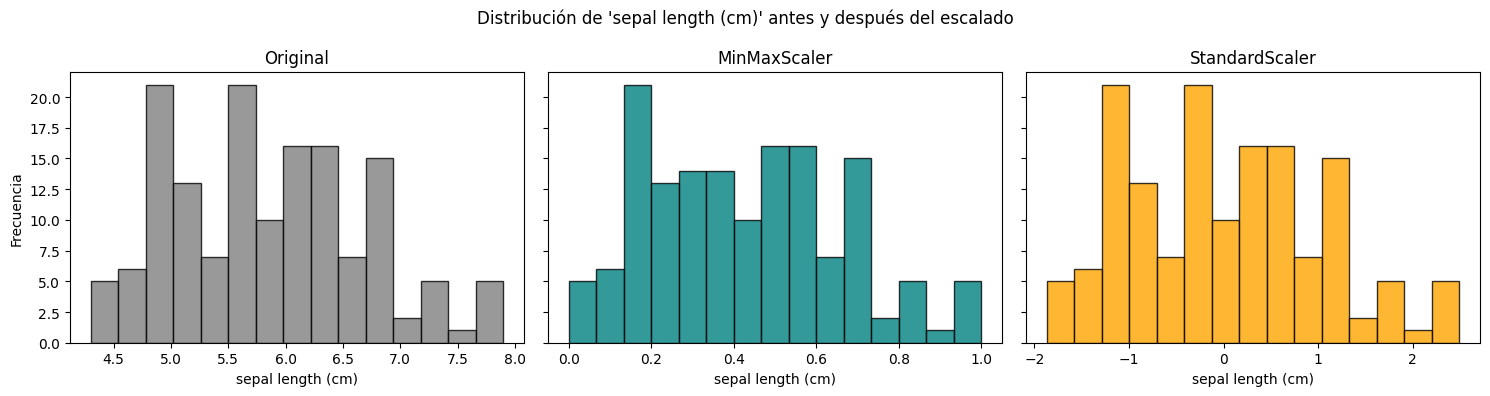

In [7]:
feature = 'sepal length (cm)'

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(data[feature], bins=15, color='gray', edgecolor='black', alpha=0.8)
axes[0].set_title('Original')
axes[0].set_xlabel(feature)
axes[0].set_ylabel('Frecuencia')

axes[1].hist(data_minmax[feature], bins=15, color='teal', edgecolor='black', alpha=0.8)
axes[1].set_title('MinMaxScaler')
axes[1].set_xlabel(feature)

axes[2].hist(data_standard[feature], bins=15, color='orange', edgecolor='black', alpha=0.8)
axes[2].set_title('StandardScaler')
axes[2].set_xlabel(feature)

plt.suptitle("Distribución de 'sepal length (cm)' antes y después del escalado")
plt.tight_layout()
plt.show()

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

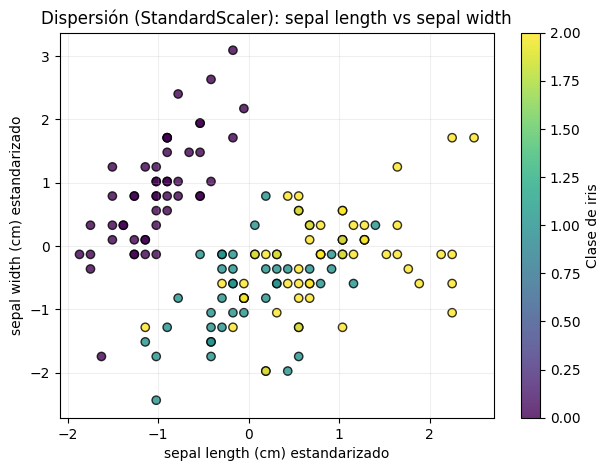

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(
    data_standard['sepal length (cm)'],
    data_standard['sepal width (cm)'],
    c=iris.target,
    cmap='viridis',
    alpha=0.8,
    edgecolors='k'
)

plt.title("Dispersión (StandardScaler): sepal length vs sepal width")
plt.xlabel('sepal length (cm) estandarizado')
plt.ylabel('sepal width (cm) estandarizado')
plt.colorbar(label='Clase de iris')
plt.grid(alpha=0.2)
plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

In [9]:
summary_standard = data_standard.describe().loc[['mean', 'std']].round(2)
summary_minmax = data_minmax.describe().loc[['min', 'max']].round(2)

print("Resumen StandardScaler (debe acercarse a media=0 y std=1):")
display(summary_standard)

print("Resumen MinMaxScaler (debe quedar entre 0 y 1):")
display(summary_minmax)

print("Respuesta:")
print(
    "Para este conjunto de datos, StandardScaler suele ser más adecuado si se usarán "
    "modelos sensibles a escala (regresión logística, SVM, KNN), porque centra y "
    "normaliza la varianza de cada variable. MinMaxScaler también es válido, pero "
    "puede ser más sensible a valores extremos."
)

Resumen StandardScaler (debe acercarse a media=0 y std=1):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


Resumen MinMaxScaler (debe quedar entre 0 y 1):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


Respuesta:
Para este conjunto de datos, StandardScaler suele ser más adecuado si se usarán modelos sensibles a escala (regresión logística, SVM, KNN), porque centra y normaliza la varianza de cada variable. MinMaxScaler también es válido, pero puede ser más sensible a valores extremos.
